## Dataset EDA

In [26]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.precision", 3)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("/home/zongj/projects/EE6405_Final_Project/data")

DATASETS = {
    "reddit_posts_train": {
        "path": DATA_DIR / "reddit_posts_and_comments_train.csv",
        "group": "Reddit Advice",
        "split": "train",
        "description": "Reddit Advice (Posts + Comments) - Train",
    },
    "reddit_posts_test": {
        "path": DATA_DIR / "reddit_posts_and_comments_test.csv",
        "group": "Reddit Advice",
        "split": "test",
        "description": "Reddit Advice (Posts + Comments) - Test",
    },
    "reddit_aita_train": {
        "path": DATA_DIR / "redditAITA_train_cleaned.csv",
        "group": "Reddit AITA",
        "split": "train",
        "description": "Reddit AITA - Train",
    },
    "reddit_aita_test": {
        "path": DATA_DIR / "redditAITA_test_cleaned.csv",
        "group": "Reddit AITA",
        "split": "test",
        "description": "Reddit AITA - Test",
    },
    "stance_twitter_train": {
        "path": DATA_DIR / "stance_data_cleaned_train.csv",
        "group": "Twitter Stance",
        "split": "train",
        "description": "Twitter Stance - Train",
    },
    "stance_twitter_test": {
        "path": DATA_DIR / "stance_data_cleaned_test.csv",
        "group": "Twitter Stance",
        "split": "test",
        "description": "Twitter Stance - Test",
    },
}

DATASETS

{'reddit_posts_train': {'path': PosixPath('/home/zongj/projects/EE6405_Final_Project/data/reddit_posts_and_comments_train.csv'),
  'group': 'Reddit Advice',
  'split': 'train',
  'description': 'Reddit Advice (Posts + Comments) - Train'},
 'reddit_posts_test': {'path': PosixPath('/home/zongj/projects/EE6405_Final_Project/data/reddit_posts_and_comments_test.csv'),
  'group': 'Reddit Advice',
  'split': 'test',
  'description': 'Reddit Advice (Posts + Comments) - Test'},
 'reddit_aita_train': {'path': PosixPath('/home/zongj/projects/EE6405_Final_Project/data/redditAITA_train_cleaned.csv'),
  'group': 'Reddit AITA',
  'split': 'train',
  'description': 'Reddit AITA - Train'},
 'reddit_aita_test': {'path': PosixPath('/home/zongj/projects/EE6405_Final_Project/data/redditAITA_test_cleaned.csv'),
  'group': 'Reddit AITA',
  'split': 'test',
  'description': 'Reddit AITA - Test'},
 'stance_twitter_train': {'path': PosixPath('/home/zongj/projects/EE6405_Final_Project/data/stance_data_cleaned_tr

## Analysis

In [37]:
def normalize_whitespace(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return " ".join(text.split())


def load_dataset(path: Path, text_columns: Iterable[str]) -> pd.DataFrame:
    df = pd.read_csv(path)
    for col in text_columns:
        if col in df:
            df[col] = df[col].apply(normalize_whitespace)
    return df

def plot_class_balance(df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(4.5, 4))
    counts = df["stance"].value_counts()
    base_order = ["concur", "oppose", "neutral"]
    ordered = [label for label in base_order if label in counts.index]
    ordered += [label for label in counts.index if label not in ordered]
    palette = dict(zip(ordered, sns.color_palette("Set2", len(ordered))))
    ax = sns.countplot(
        data=df,
        x="stance",
        hue="stance",
        order=ordered,
        hue_order=ordered,
        palette=palette,
        legend=False,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%d")
    ax.set_title(title)
    ax.set_xlabel("Stance label")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

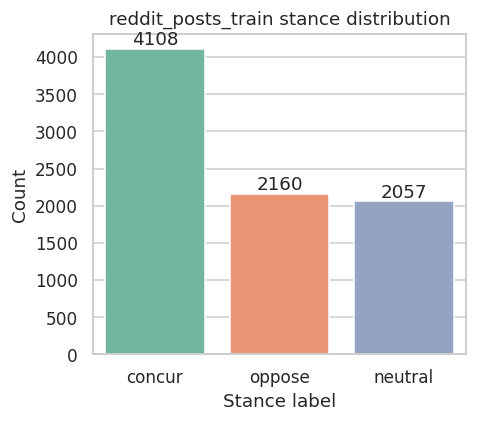

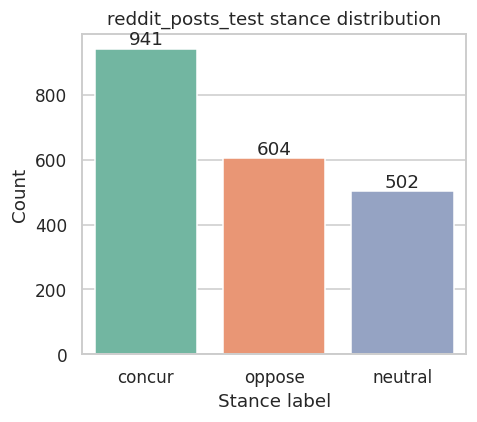

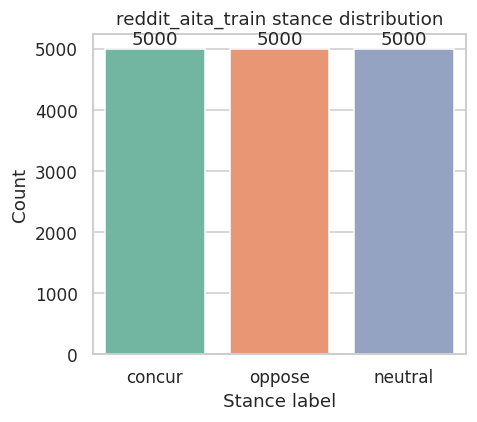

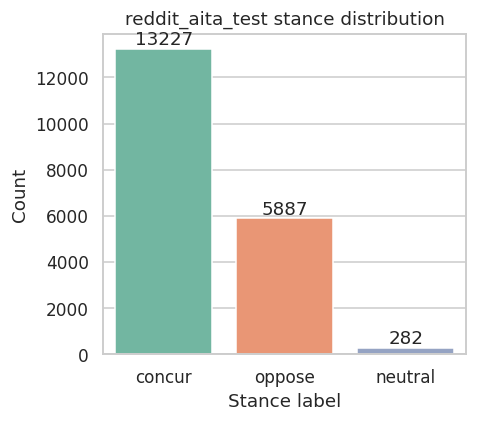

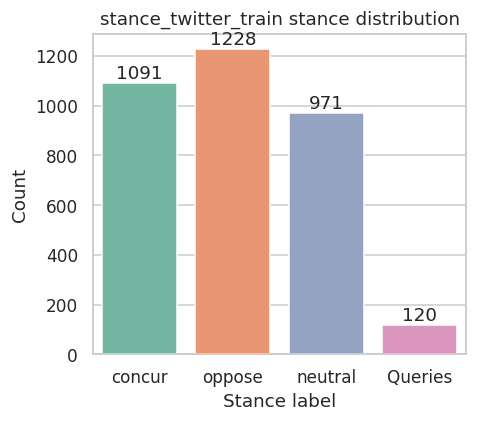

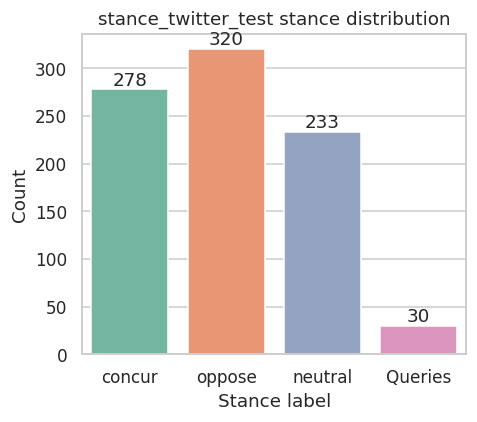

In [38]:
for name, df in prepared_dfs.items():
    plot_class_balance(df, f"{name} stance distribution")